# **Worksheet 5 – CNN for Fruit Classification (Amazon Fruits Dataset)**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import random
from sklearn.metrics import classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/AI_Machine_Learning/Week5/FruitinAmazon.zip"
extract_path = "/content/FruitinAmazon"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")


Mounted at /content/drive
Unzipped successfully!


## **Task 1 – Data Understanding & Visualization**

In [ ]:
# Paths for Google Colab
train_dir = "/content/FruitinAmazon/FruitinAmazon/train"
test_dir = "/content/FruitinAmazon/FruitinAmazon/test"

# Check classes
class_names = sorted(os.listdir(train_dir))
print("Classes found:", class_names)

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


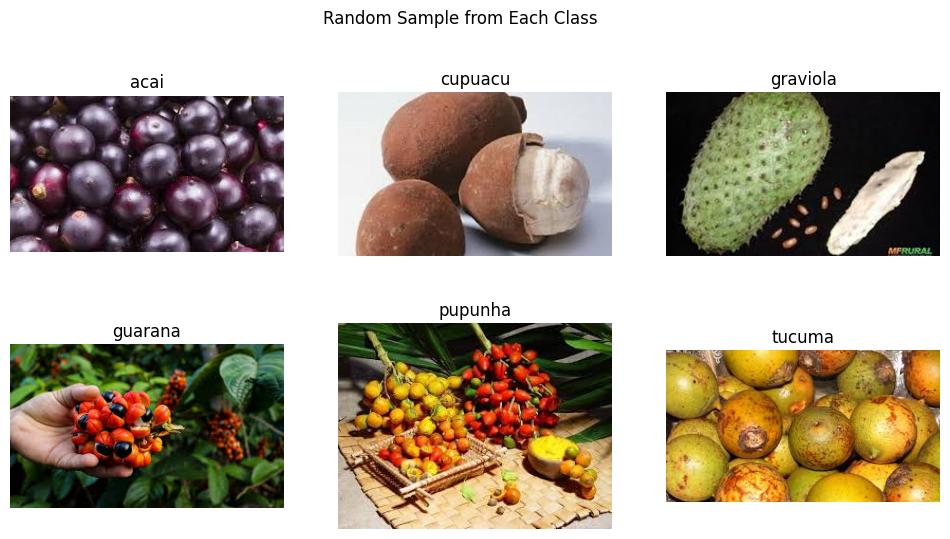

Observation: Each fruit class has visually distinct shapes & textures, supporting CNN learning.


In [ ]:
# === DISPLAY ONE RANDOM IMAGE FROM EACH CLASS ===

plt.figure(figsize=(12, 6))

for i, cls in enumerate(class_names):
    cls_path = os.path.join(train_dir, cls)
    img_file = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_file)

    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Random Sample from Each Class")
plt.show()

print("Observation: Each fruit class has visually distinct shapes & textures, supporting CNN learning.")

### ✔ Task 1.2 – Corrupted Image Checker

In [ ]:
corrupted = []

for cls in class_names:
    cls_path = os.path.join(train_dir, cls)
    for file in os.listdir(cls_path):
        img_path = os.path.join(cls_path, file)
        try:
            img = Image.open(img_path)
            img.verify()  # verify integrity
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No corrupted images found!")

No corrupted images found!


## **Task 2 – Load & Preprocess Data (Keras image_dataset_from_directory)**

In [ ]:
img_height = 128
img_width = 128
batch_size = 16

# Load training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=123
)

# Load validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=123
)

# Load test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Normalize using Rescaling layer
rescale = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))
test_ds  = test_ds.map(lambda x, y: (rescale(x), y))

print("Datasets loaded and normalized!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Datasets loaded and normalized!


## **Task 3 – Build CNN Model**

In [ ]:
model = tf.keras.Sequential([
    # Conv Layer 1
    tf.keras.layers.Conv2D(32, (3,3), padding='same', strides=1, activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D((2,2), strides=2),

    # Conv Layer 2
    tf.keras.layers.Conv2D(32, (3,3), padding='same', strides=1, activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2), strides=2),

    # Dense Layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(6, activation='softmax')   # 6 classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## **Task 4 – Compile & Train Model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_cnn_model.h5", save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=callbacks
)

print("Model training complete!")

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.2087 - loss: 1.8927

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 361ms/step - accuracy: 0.1944 - loss: 1.8922 - val_accuracy: 0.0556 - val_loss: 1.8668
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.1743 - loss: 1.7987

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 0.1944 - loss: 1.7687 - val_accuracy: 0.1667 - val_loss: 1.8428
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.2736 - loss: 1.6919

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - accuracy: 0.2639 - loss: 1.6826 - val_accuracy: 0.1111 - val_loss: 1.7849
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step - accuracy: 0.5139 - loss: 1.5766 - val_accuracy: 0.1111 - val_loss: 1.7866
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.5181 - loss: 1.4781

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step - accuracy: 0.5694 - loss: 1.4684 - val_accuracy: 0.2222 - val_loss: 1.7007
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 494ms/step - accuracy: 0.5694 - loss: 1.3696 - val_accuracy: 0.1667 - val_loss: 1.7515
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.8014 - loss: 1.2387

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 494ms/step - accuracy: 0.8194 - loss: 1.2490 - val_accuracy: 0.3333 - val_loss: 1.6018
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 283ms/step - accuracy: 0.8889 - loss: 1.1314 - val_accuracy: 0.3889 - val_loss: 1.7391
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9319 - loss: 1.0274

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - accuracy: 0.9306 - loss: 1.0242 - val_accuracy: 0.3889 - val_loss: 1.5160
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 278ms/step - accuracy: 0.9861 - loss: 0.9427 - val_accuracy: 0.3889 - val_loss: 1.6095
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 307ms/step - accuracy: 0.9861 - loss: 0.8324 - val_accuracy: 0.3889 - val_loss: 1.6143
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 1.0000 - loss: 0.7402

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 369ms/step - accuracy: 1.0000 - loss: 0.7241 - val_accuracy: 0.3889 - val_loss: 1.5141
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 482ms/step - accuracy: 1.0000 - loss: 0.6340 - val_accuracy: 0.3889 - val_loss: 1.5553
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 1.0000 - loss: 0.5635

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 431ms/step - accuracy: 1.0000 - loss: 0.5580 - val_accuracy: 0.3889 - val_loss: 1.4787
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 272ms/step - accuracy: 1.0000 - loss: 0.4921 - val_accuracy: 0.4444 - val_loss: 1.4959
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - accuracy: 1.0000 - loss: 0.4372 - val_accuracy: 0.5000 - val_loss: 1.5324
Epoch 17/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step - accuracy: 1.0000 - loss: 0.3853 - val_accuracy: 0.4444 - val_loss: 1.5291
Epoch 18/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 629ms/step - accuracy: 1.0000 - loss: 0.3433 - val_accuracy: 0.4444 - val_loss: 1.5122
Epoch 19/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 610ms/step - accuracy: 1.0000 - loss: 0.3067 - val_accuracy: 0.4444 - val_loss: 1.5098
Epoch 20/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step - accuracy: 1.0000 - loss: 0.2758 - val_accuracy: 0.4444 - val_loss: 1.5527
Epoch 21/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 285ms/step - accuracy: 1.0000 - loss: 0.2490 - val_accuracy: 0.4444 - val_lo

### 📊 Training Curves

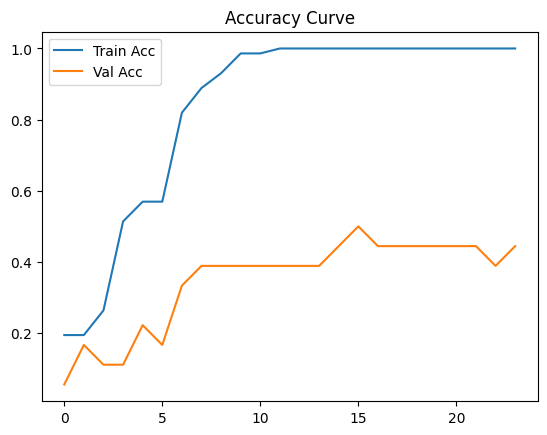

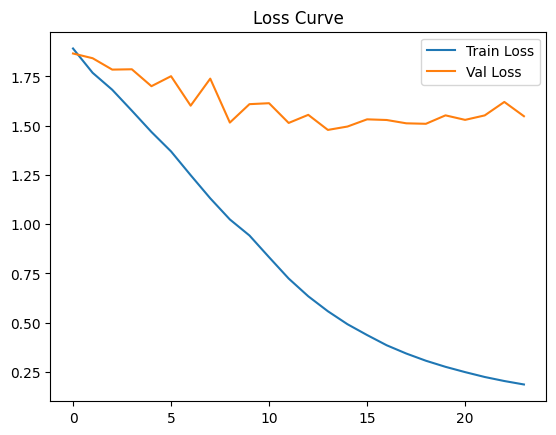

In [ ]:
# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

## **Task 5 – Evaluate on Test Set**

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.7667 - loss: 1.0863
Test Accuracy: 0.7666666507720947
Test Loss: 1.0863478183746338


## **Task 6 – Save and Load Model**

In [ ]:
model.save("final_fruit_cnn_model.h5")

loaded_model = tf.keras.models.load_model("final_fruit_cnn_model.h5")

loaded_model.evaluate(test_ds)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - accuracy: 0.7667 - loss: 1.0863


[1.0863478183746338, 0.7666666507720947]

## **Task 7 – Predictions + Classification Report**

In [ ]:
y_true = []
y_pred = []

for X, y in test_ds:
    preds = loaded_model.predict(X)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step
              precision    recall  f1-score   support

        acai       0.56      1.00      0.71         5
     cupuacu       1.00      0.60      0.75         5
    graviola       0.71      1.00      0.83         5
     guarana       1.00      0.80      0.89         5
     pupunha       1.00      0.80      0.89         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.77        30
   macro avg       0.82      0.77      0.76        30
weighted avg       0.82      0.77      0.76        30

